In [7]:
import sys

In [8]:
import matplotlib.pyplot as plt
import torch
import torchaudio


In [9]:
from authtransforms.pipeline import Compose, OneOf, SomeOf
from authtransforms.transforms import (
    AddGaussianNoise,
    Normalize,
    RandomApply,
    RandomClip,
    RandomGain,
    RandomPitchShift,
    RandomSpeedChange,
    TimeShift,
    ToMono,
    CodecAugmentation,
    FilterAugmentation
)
from authtransforms.utils import _play_notebook,_play_script,audio_info, compare_audio, compare_play, plot_audio,play_audio


In [11]:
from pathlib import Path

audio_path="121_127105_000007_000004.wav"
audio,sample_rate=torchaudio.load(audio_path)
print(f"Loaded:{audio_path}")
audio_info(audio, sample_rate, label="Original")

Loaded:121_127105_000007_000004.wav
[Original]
  Shape      : (1, 184080)
  Channels   : 1
  Sample rate: 24000 Hz
  Duration   : 7.670 s  (184080 samples)
  Peak       : 0.4513
  RMS        : 0.0446  (-27.0 dBFS)
  dtype      : torch.float32


/Users/santriasjohnson/Library/Caches/pypoetry/virtualenvs/authtransforms-UtV5z0rD-py3.11/lib/python3.11/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [5]:
transformation=RandomClip(sample_rate=sample_rate,clip_length=sample_rate*5,vad=True)
augmented=transformation(audio)
audio_info(augmented,sample_rate,label="Augmented")
    

[Augmented]
  Shape      : (1, 112800)
  Channels   : 1
  Sample rate: 24000 Hz
  Duration   : 4.700 s  (112800 samples)
  Peak       : 0.4128
  RMS        : 0.0400  (-28.0 dBFS)
  dtype      : torch.float32


In [6]:
transformation=RandomClip(sample_rate=sample_rate,clip_length=sample_rate*5)
augmented_1=transformation(audio)
audio_info(augmented,sample_rate,label="Augmented")
    

[Augmented]
  Shape      : (1, 110400)
  Channels   : 1
  Sample rate: 24000 Hz
  Duration   : 4.600 s  (110400 samples)
  Peak       : 0.4128
  RMS        : 0.0405  (-27.8 dBFS)
  dtype      : torch.float32


In [7]:
play_audio(augmented,sample_rate)

/Users/santriasjohnson/Library/Caches/pypoetry/virtualenvs/authtransforms-UtV5z0rD-py3.11/lib/python3.11/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(


In [8]:
tfm1=OneOf([
    RandomClip(sample_rate=sample_rate,clip_length=sample_rate *4), 
    RandomPitchShift(sample_rate=sample_rate,semitones=(-2,2)) , 
    RandomSpeedChange(sample_rate=sample_rate,speed_factors=[0.9,1.1])
])


In [9]:
augment_2=tfm1(audio)

/Users/santriasjohnson/audio-transforms/src/authtransforms/transforms.py:163: UserWarning: torchaudio.sox_effects.sox_effects.apply_effects_tensor has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  transformed, _ = torchaudio.sox_effects.apply_effects_tensor(


In [10]:
play_audio(augment_2,sample_rate)

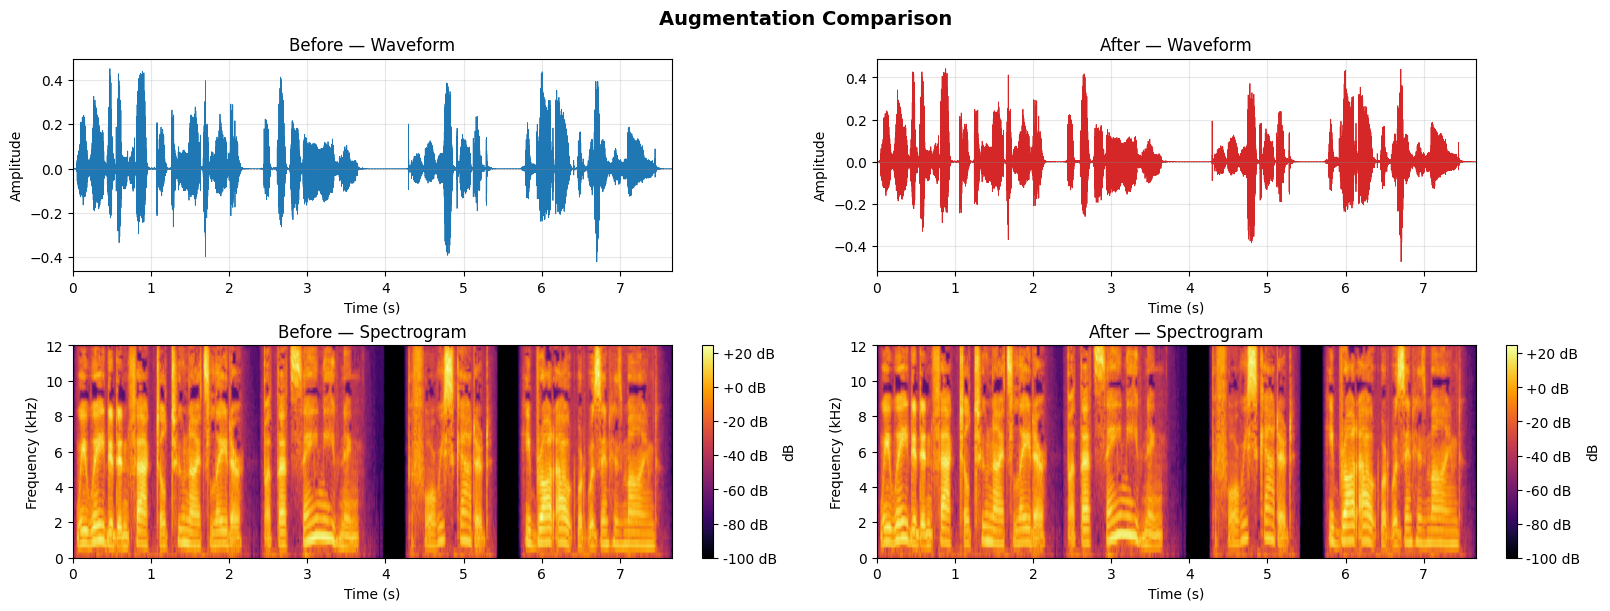

In [11]:
augment_2_plt=compare_audio(before=audio,after=augment_2,sample_rate=sample_rate)

In [18]:
util_1=_play_script(augment_2,sample_rate=sample_rate)

In [17]:
util_2=_play_notebook(augment_2,sample_rate=sample_rate)

/Users/santriasjohnson/Library/Caches/pypoetry/virtualenvs/authtransforms-UtV5z0rD-py3.11/lib/python3.11/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(


In [8]:
augment_3=CodecAugmentation(sample_rate,codecs=("aac"))
aug_3=augment_3(audio)

## play_audio(aug_3,sample_rate)

In [22]:
augment_4=CodecAugmentation(sample_rate,codecs=("g722",),p=0.3)
aug_4=augment_4(audio)

/Users/santriasjohnson/Library/Caches/pypoetry/virtualenvs/authtransforms-UtV5z0rD-py3.11/lib/python3.11/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(
/Users/santriasjohnson/Library/Caches/pypoetry/virtualenvs/authtransforms-UtV5z0rD-py3.11/lib/python3.11/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on

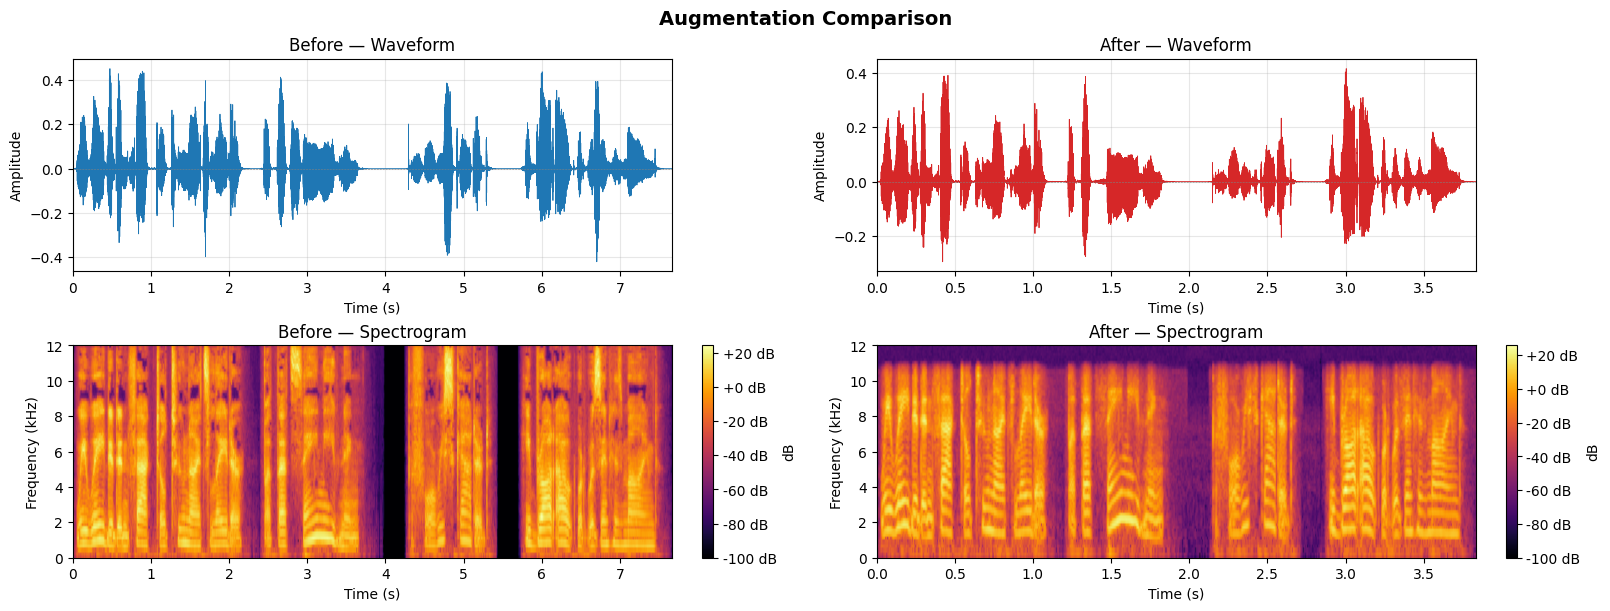

In [23]:
spectro_2=compare_audio(before=aug_3,after=aug_4,sample_rate=sample_rate)

In [12]:
augment_5=FilterAugmentation(sample_rate=16000, low_hz=300, high_hz=3400, p=1.0)
aug_5=augment_5(audio)


ValueError: At least one stride in the given numpy array is negative, and tensors with negative strides are not currently supported. (You can probably work around this by making a copy of your array  with array.copy().) 

In [27]:
play_5=play_audio(aug_5,sample_rate)

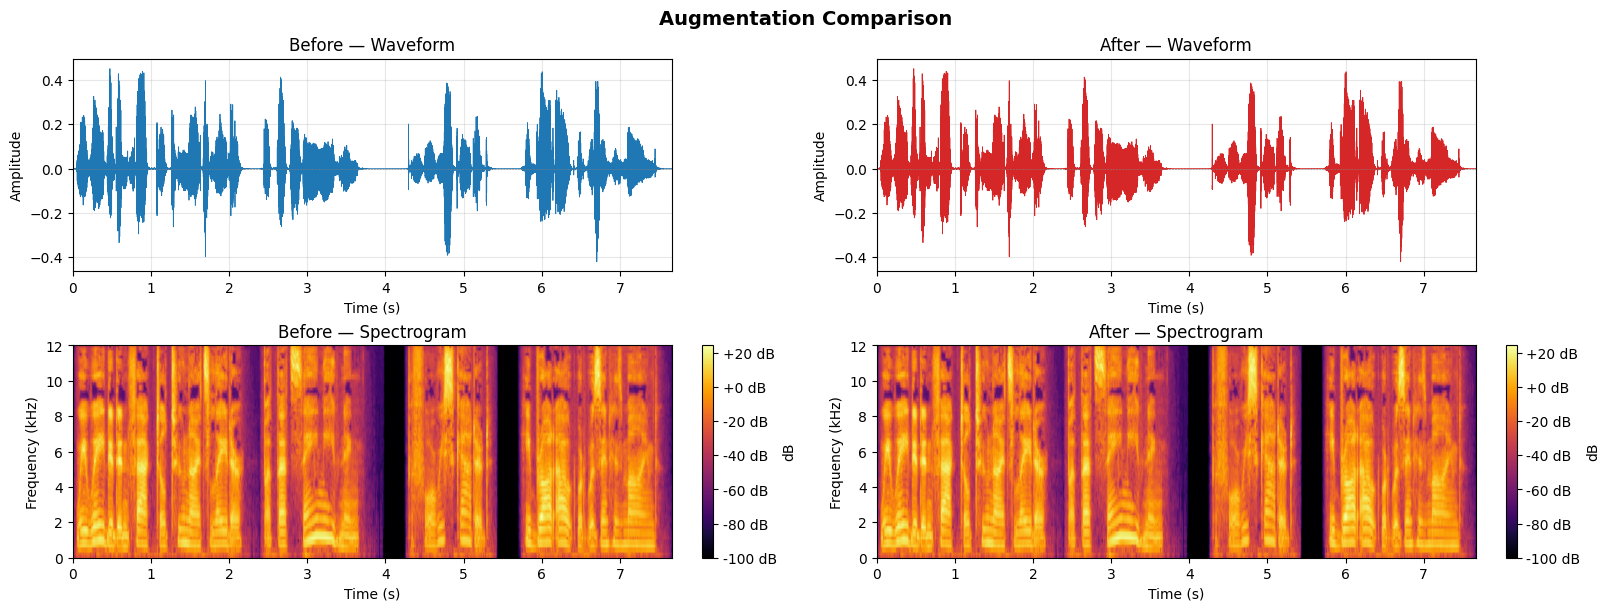

In [28]:
spectro_2=compare_audio(before=audio,after=aug_5,sample_rate=sample_rate)